# Task 27: Assignment

Q1. (Creating Non-Linear Dataset)

Generate a synthetic dataset using make_moons with:

n_samples=500

noise=0.05

random_state=42

Convert it into a DataFrame with columns Feature1 and Feature2.

Display the first 10 rows and shape of the dataset.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, make_blobs, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

In [2]:
# Generate synthetic dataset using make_moons
X, y = make_moons(n_samples=500, noise=0.05, random_state=42)

# Convert into a DataFrame
df_moon = pd.DataFrame(X, columns=['Feature1', 'Feature2'])

# Display shape and first 10 rows
print("Shape of Dataset:", df_moon.shape)
print("\nFirst 10 Rows:")
print(df_moon.head(10))

Shape of Dataset: (500, 2)

First 10 Rows:
   Feature1  Feature2
0  0.830586 -0.447733
1  0.701678  0.816918
2  1.022080 -0.492571
3 -0.316765  0.953438
4  0.293226  1.057185
5  1.254903 -0.483435
6  1.053851 -0.442690
7  0.031380  1.053012
8  0.620545  0.713096
9  1.787657 -0.142959


Q2. (Scaling the Data)

Apply Standard Scaling on the dataset created in Q1.

Use StandardScaler.

Store the scaled data in X_scaled.

Show the first 5 rows of the scaled data.


In [3]:
# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_moon[['Feature1', 'Feature2']])

# Show first 5 rows of scaled data
print("First 5 rows of X_scaled:")
print(X_scaled[:5])

First 5 rows of X_scaled:
[[ 0.37512461 -1.40367864]
 [ 0.22681458  1.13562771]
 [ 0.59544154 -1.49371022]
 [-0.94491835  1.40974769]
 [-0.24311512  1.61806199]]


Q3. (K-Means on Non-Linear Data)

Apply KMeans clustering with n_clusters=2 on the scaled moon dataset.

Fit and predict the cluster labels.

Add the labels to the DataFrame as kmeans_cluster.

Create a scatter plot to visualize the KMeans clusters.


c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

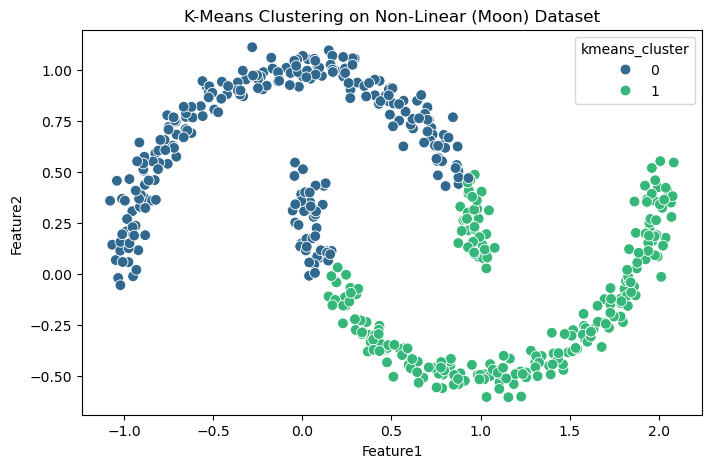

In [4]:
# Apply KMeans clustering with n_clusters = 2
kmeans = KMeans(n_clusters=2, random_state=42)
df_moon['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# Plot KMeans Clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Feature1', y='Feature2', hue='kmeans_cluster', data=df_moon, palette='viridis', s=60)
plt.title('K-Means Clustering on Non-Linear (Moon) Dataset')
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.show()

Q4. (DBSCAN Clustering)

Apply DBSCAN on the same scaled data with:

eps=0.3

min_samples=5

Predict the cluster labels.

Add the labels to the DataFrame as dbscan_cluster.

Create a scatter plot to visualize the DBSCAN clusters (including noise points
if any).



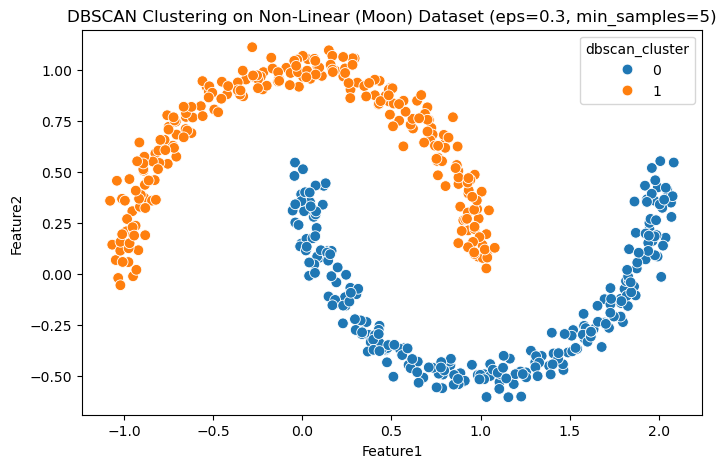

In [5]:
# Apply DBSCAN with eps = 0.3, min_samples = 5
dbscan = DBSCAN(eps=0.3, min_samples=5)
df_moon['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# Plot DBSCAN Clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Feature1', y='Feature2', hue='dbscan_cluster', data=df_moon, palette='tab10', s=60)
plt.title('DBSCAN Clustering on Non-Linear (Moon) Dataset (eps=0.3, min_samples=5)')
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.show()

Q5. (Comparing KMeans vs DBSCAN)

Using the plots from Q3 and Q4:

Compare the clustering results of KMeans and DBSCAN visually.

Write observations about how DBSCAN handles non-spherical clusters and
noise better than KMeans.


1. Cluster Shapes
K-Means: Only works well with round/spherical clusters. It fails on curved or non-linear shapes (like the moon dataset).

DBSCAN: Works with any shape (crescents, rings, complex curves) because it groups points based on density.

2. Noise & Outliers
K-Means: Forces every point into a cluster, even extreme outliers.

DBSCAN: Detects isolated points and labels them as noise (-1).

Q6. (Tuning DBSCAN Parameters)

Experiment with different values of eps (e.g., 0.2, 0.3, 0.4, 0.5) while keeping
min_samples=5.

For each value, apply DBSCAN and count the number of clusters and noise
points.

Create a small table showing eps, number of clusters, and number of noise
points.

Write which eps value worked best for the moon dataset.


In [6]:
eps_values = [0.2, 0.3, 0.4, 0.5]
results = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)
    
    # Count clusters (excluding noise label -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    # Count noise points (label == -1)
    n_noise = list(labels).count(-1)
    
    results.append({
        'eps': eps,
        'Number of Clusters': n_clusters,
        'Noise Points': n_noise
    })

# Display summary table
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 eps  Number of Clusters  Noise Points
 0.2                   2             0
 0.3                   2             0
 0.4                   2             0
 0.5                   2             0


Q7. (Creating High-Dimensional Dataset)

Generate a synthetic dataset using make_blobs with:

n_samples=500

n_features=6

centers=4
cluster_std=1.5

random_state=42

Scale the data using StandardScaler.

In [7]:
# Generate synthetic high-dimensional dataset
X_blob, y_blob = make_blobs(n_samples=500, n_features=6, centers=4, cluster_std=1.5, random_state=42)

# Scale data using StandardScaler
scaler_blob = StandardScaler()
X_blob_scaled = scaler_blob.fit_transform(X_blob)

print("Shape of Scaled High-Dimensional Data:", X_blob_scaled.shape)

Shape of Scaled High-Dimensional Data: (500, 6)


Q8. (Applying PCA)

Apply PCA on the scaled high-dimensional data from Q7:

Reduce the dimensions to 2 principal components.

Create a DataFrame with columns PC1 and PC2.

Add the original cluster labels (from make_blobs) to the DataFrame.

Display the explained variance ratio of the two components.


In [8]:
# Apply PCA to reduce dimensions from 6 to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_blob_scaled)

# Create DataFrame
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Target'] = y_blob

# Display Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio per Component:", explained_variance)
print(f"Total Retained Variance: {np.sum(explained_variance) * 100:.2f}%")

Explained Variance Ratio per Component: [0.64327878 0.21039738]
Total Retained Variance: 85.37%


Q9. (Visualizing PCA Results)

Create a scatter plot of the 2 principal components obtained in Q8.

Color the points based on the original cluster labels.

Add a proper title and axis labels.

Write what the explained variance tells you about information retained.


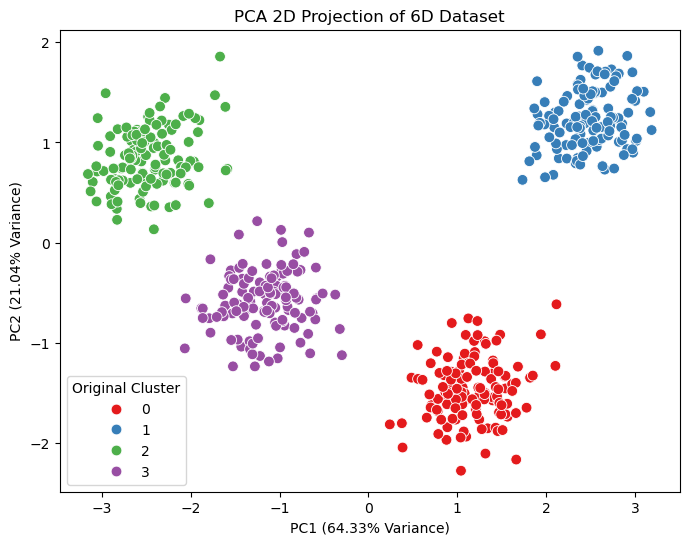

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Target', data=df_pca, palette='Set1', s=60)
plt.title('PCA 2D Projection of 6D Dataset')
plt.xlabel(f'PC1 ({explained_variance[0]*100:.2f}% Variance)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.2f}% Variance)')
plt.legend(title='Original Cluster')
plt.show()

Q10. (Mini Project – Complete Pipeline)

Choose a real-world dataset with multiple numerical features (e.g., Iris, Wine, or
any dataset of your choice).

Perform the complete pipeline:
1. Load and select numerical features
2. Scale the data
3. Apply DBSCAN and visualize (if possible in 2D)
4. Apply PCA to reduce to 2 components
5. Visualize the PCA results


DBSCAN Cluster Counts 
DBSCAN_Cluster
 0    154
-1     24
Name: count, dtype: int64


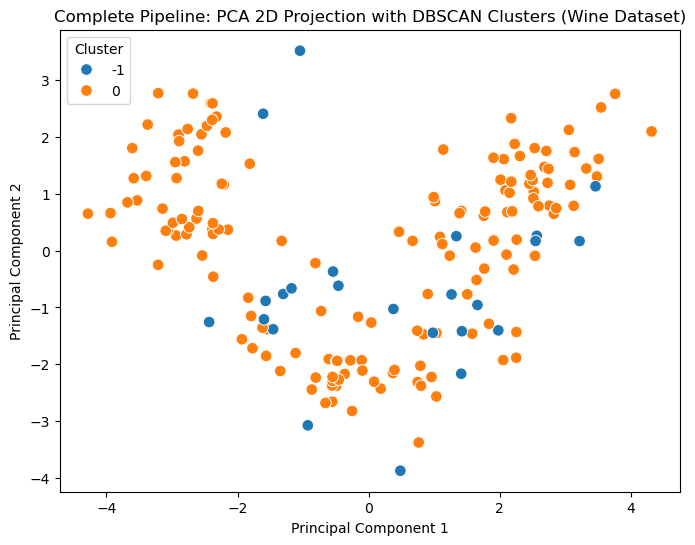

In [10]:
# 1. Load Real-World Dataset (Wine Dataset)
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)

# 2. Select numerical features and scale them
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(df_wine)

# 3. Apply DBSCAN
dbscan_wine = DBSCAN(eps=2.5, min_samples=5)
df_wine['DBSCAN_Cluster'] = dbscan_wine.fit_predict(X_wine_scaled)

print("DBSCAN Cluster Counts ")
print(df_wine['DBSCAN_Cluster'].value_counts())

# 4. Apply PCA to reduce to 2 components
pca_wine = PCA(n_components=2)
X_wine_pca = pca_wine.fit_transform(X_wine_scaled)

df_wine_pca = pd.DataFrame(X_wine_pca, columns=['PC1', 'PC2'])
df_wine_pca['Cluster'] = df_wine['DBSCAN_Cluster']

# 5. Visualize PCA Results
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_wine_pca, palette='tab10', s=70)
plt.title('Complete Pipeline: PCA 2D Projection with DBSCAN Clusters (Wine Dataset)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()